<a href="https://colab.research.google.com/github/ibu-47/DBT_Intern/blob/main/Ensemble_Learning_Stacking_(Random_Forest%2C_LSTM%2C_BERT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets tqdm scikit-learn joblib

In [3]:
import pandas as pd
import numpy as np
import torch
import os
import joblib
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Setup for BERT and LSTM
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tqdm import tqdm

# --- 1. CONFIGURATION ---
DATA_PATH = 'mental_health.csv'
N_SPLITS = 5
MAX_LEN_BERT = 128
MAX_LEN_LSTM = 100
MAX_WORDS_LSTM = 10000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# --- 2. HELPER CLASSES ---
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        encoding = self.tokenizer(str(self.texts[item]), truncation=True, padding='max_length',
                                  max_length=self.max_len, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(self.labels[item], dtype=torch.long)}

# --- 3. MASTER STACKING LOOP ---
def run_kfold_stacking():
    if not os.path.exists(DATA_PATH):
        print(f"Error: {DATA_PATH} not found. Please upload it to the Colab file area.")
        return

    df = pd.read_csv(DATA_PATH).dropna().reset_index(drop=True)
    le = LabelEncoder()
    df['label_id'] = le.fit_transform(df['label'])

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    meta_features = np.zeros((len(df), 3))

    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        print(f"\n🚀 STARTING FOLD {fold+1}/{N_SPLITS}")

        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        # --- PART A: RANDOM FOREST ---
        print("Training Random Forest...")
        tfidf = TfidfVectorizer(max_features=5000)
        X_train_rf = tfidf.fit_transform(train_df['text'])
        X_val_rf = tfidf.transform(val_df['text'])

        from sklearn.ensemble import RandomForestClassifier
        rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
        rf.fit(X_train_rf, train_df['label_id'])
        meta_features[val_idx, 0] = rf.predict_proba(X_val_rf)[:, 1]

        # --- PART B: LSTM ---
        print("Training LSTM...")
        tokenizer_lstm = Tokenizer(num_words=MAX_WORDS_LSTM)
        tokenizer_lstm.fit_on_texts(train_df['text'])
        X_train_lstm = pad_sequences(tokenizer_lstm.texts_to_sequences(train_df['text']), maxlen=MAX_LEN_LSTM)
        X_val_lstm = pad_sequences(tokenizer_lstm.texts_to_sequences(val_df['text']), maxlen=MAX_LEN_LSTM)

        lstm_model = Sequential([
            Embedding(MAX_WORDS_LSTM, 128, input_length=MAX_LEN_LSTM),
            LSTM(64),
            Dense(1, activation='sigmoid')
        ])
        lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        lstm_model.fit(X_train_lstm, train_df['label_id'], epochs=3, batch_size=64, verbose=0)
        meta_features[val_idx, 1] = lstm_model.predict(X_val_lstm).flatten()

        # --- PART C: BERT ---
        print("Training BERT...")
        bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        train_ds = MentalHealthDataset(train_df['text'].values, train_df['label_id'].values, bert_tokenizer, MAX_LEN_BERT)
        val_ds = MentalHealthDataset(val_df['text'].values, val_df['label_id'].values, bert_tokenizer, MAX_LEN_BERT)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=32)

        bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(DEVICE)
        optimizer = AdamW(bert_model.parameters(), lr=2e-5)

        bert_model.train()
        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Training"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            optimizer.step()

        bert_model.eval()
        fold_bert_probs = []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                logits = bert_model(input_ids, attention_mask=attention_mask).logits
                probs = torch.nn.functional.softmax(logits, dim=-1)
                fold_bert_probs.extend(probs[:, 1].cpu().numpy())
        meta_features[val_idx, 2] = fold_bert_probs

        # Free up memory
        del bert_model
        torch.cuda.empty_cache()

    # --- 4. FINAL META-LEARNER TRAINING ---
    print("\n✅ K-Fold Complete. Training Meta-Learner...")
    X_meta = meta_features
    y_meta = df['label_id'].values

    meta_learner = LogisticRegression()
    meta_learner.fit(X_meta, y_meta)

    meta_df = pd.DataFrame(X_meta, columns=['rf_prob', 'lstm_prob', 'bert_prob'])
    meta_df['true_label'] = y_meta
    meta_df.to_csv('kfold_meta_dataset_PRO.csv', index=False)

    joblib.dump(meta_learner, 'final_stacking_meta_learner.pkl')
    print("Files saved: 'kfold_meta_dataset_PRO.csv' and 'final_stacking_meta_learner.pkl'")

if __name__ == "__main__":
    run_kfold_stacking()

Using device: cuda

🚀 STARTING FOLD 1/5
Training Random Forest...
Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Training BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Training BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Fold 5 Training: 100%|██████████| 611


✅ K-Fold Complete. Training Meta-Learner...
Files saved: 'kfold_meta_dataset_PRO.csv' and 'final_stacking_meta_learner.pkl'


In [4]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the clean K-Fold results
df = pd.read_csv('kfold_meta_dataset_PRO.csv')
X_meta = df[['rf_prob', 'lstm_prob', 'bert_prob']]
y_true = df['true_label']

# 2. Load the trained Meta-Learner
meta_learner = joblib.load('final_stacking_meta_learner.pkl')
meta_preds = meta_learner.predict(X_meta)

# 3. Compare all models
models = {
    "Random Forest": (df['rf_prob'] > 0.5).astype(int),
    "LSTM": (df['lstm_prob'] > 0.5).astype(int),
    "BERT": (df['bert_prob'] > 0.5).astype(int),
    "Stacked Ensemble": meta_preds
}

print("📊 FINAL COMPARISON REPORT")
for name, preds in models.items():
    acc = accuracy_score(y_true, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_true, preds))

📊 FINAL COMPARISON REPORT

Random Forest Accuracy: 0.8927
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     12057
           1       0.90      0.88      0.89     12349

    accuracy                           0.89     24406
   macro avg       0.89      0.89      0.89     24406
weighted avg       0.89      0.89      0.89     24406


LSTM Accuracy: 0.9153
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     12057
           1       0.92      0.92      0.92     12349

    accuracy                           0.92     24406
   macro avg       0.92      0.92      0.92     24406
weighted avg       0.92      0.92      0.92     24406


BERT Accuracy: 0.9557
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     12057
           1       0.96      0.95      0.96     12349

    accuracy                           0.96     24406
   macro avg       0.96 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


/tmp/ipython-input-397/2429941215.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=accuracies, palette='viridis')


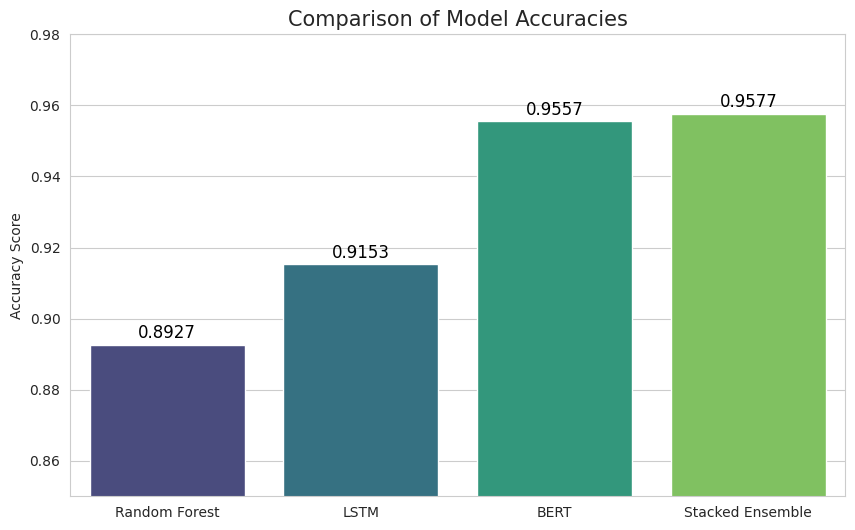

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your results
models = ['Random Forest', 'LSTM', 'BERT', 'Stacked Ensemble']
accuracies = [0.8927, 0.9153, 0.9557, 0.9577]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=models, y=accuracies, palette='viridis')

# Adding labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 8),
                textcoords='offset points')

plt.ylim(0.85, 0.98) # Zoom in to show the difference
plt.title('Comparison of Model Accuracies', fontsize=15)
plt.ylabel('Accuracy Score')
plt.show()